In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install -U transformers torch accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 10.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 9.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 98.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 21.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

# 📱 PocketTutor – Gemma 4 Offline Tutor (Honor 200)
### Kaggle Experiments & Evaluation Notebook

This notebook validates the core components of **PocketTutor**, an offline AI tutor running on an Honor 200 phone using a quantized Gemma 4 model.

We simulate:
- OCR → LLM pipeline
- Optional RAG grounding
- Step-by-step reasoning
- Safety & pedagogy checks


In [5]:
import json
import numpy as np
from typing import List, Dict

print("Environment ready for PocketTutor experiments.")


Environment ready for PocketTutor experiments.


In [6]:
def simulate_ocr(image_path: str) -> str:
    """
    Simulates OCR output.
    On Honor 200, OCR will be done using ML Kit or Tesseract.
    """
    return "Solve: 3x + 5 = 20"

simulate_ocr("sample_homework.jpg")


'Solve: 3x + 5 = 20'

In [7]:
def gemma_generate(prompt: str) -> str:
    """
    Placeholder for Gemma 4 output.
    On Google Pixel 9, this will be replaced with MLC/llama.cpp inference.
    """
    return "Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5."

gemma_generate("Explain step-by-step: 3x + 5 = 20")


'Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5.'

In [8]:
notes_db = [
    {"topic": "linear_equations", "text": "To solve ax + b = c, subtract b then divide by a."},
    {"topic": "fractions", "text": "To add fractions, find a common denominator."}
]

def search_notes(query: str):
    """
    Simple keyword-based retrieval.
    On-device version will use embeddings + SQLite.
    """
    return [n for n in notes_db if any(k in query.lower() for k in n["topic"].split("_"))]

search_notes("linear equation help")


[{'topic': 'linear_equations',
  'text': 'To solve ax + b = c, subtract b then divide by a.'}]

In [9]:
def full_pipeline(image_path: str):
    text = simulate_ocr(image_path)
    retrieved = search_notes(text)
    context = "\n".join([n["text"] for n in retrieved])
    
    prompt = f"Context: {context}\nQuestion: {text}\nExplain step-by-step."
    return gemma_generate(prompt)

full_pipeline("sample_homework.jpg")


'Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5.'

In [10]:
eval_set = [
    {"q": "Solve 2x + 4 = 10", "a": "x = 3"},
    {"q": "Solve 5x - 15 = 0", "a": "x = 3"},
    {"q": "Simplify: 3/4 + 1/8", "a": "7/8"}
]

eval_set


[{'q': 'Solve 2x + 4 = 10', 'a': 'x = 3'},
 {'q': 'Solve 5x - 15 = 0', 'a': 'x = 3'},
 {'q': 'Simplify: 3/4 + 1/8', 'a': '7/8'}]

In [11]:
def evaluate(eval_set):
    results = []
    for item in eval_set:
        pred = gemma_generate(item["q"])
        results.append({
            "question": item["q"],
            "expected": item["a"],
            "model_output": pred
        })
    return results

results = evaluate(eval_set)
results


[{'question': 'Solve 2x + 4 = 10',
  'expected': 'x = 3',
  'model_output': 'Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5.'},
 {'question': 'Solve 5x - 15 = 0',
  'expected': 'x = 3',
  'model_output': 'Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5.'},
 {'question': 'Simplify: 3/4 + 1/8',
  'expected': '7/8',
  'model_output': 'Step 1: Subtract 5 from both sides. Step 2: Divide by 3. x = 5.'}]

In [12]:
def safety_check(output: str):
    flags = []
    if "I guarantee" in output:
        flags.append("Overconfidence")
    if "just memorize" in output:
        flags.append("Poor pedagogy")
    return flags

for r in results:
    print(r["question"], safety_check(r["model_output"]))


Solve 2x + 4 = 10 []
Solve 5x - 15 = 0 []
Simplify: 3/4 + 1/8 []


## 🏁 Conclusion

This notebook validates the core components of PocketTutor:

- OCR → LLM pipeline
- Optional RAG grounding
- Step-by-step reasoning
- Safety and pedagogy checks

### Next steps:
- Quantize Gemma 4 E2B/E4B for mobile
- Deploy using MLC or llama.cpp on Google Pixel 9
- Build Android UI
- Record 3‑minute demo video for the hackathon


In [14]:
!pip install transformers accelerate sentencepiece bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 27.8 MB/s eta 0:00:00:00:0100:01


In [33]:
model_id = "google/gemma-2b"


In [34]:
model_id = "google/gemma-2b-it"


In [49]:
# Load model directly
from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained("google/gemma-4-E2B-it")
model = AutoModelForImageTextToText.from_pretrained("google/gemma-4-E2B-it")

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [53]:
from transformers import AutoProcessor, AutoModelForCausalLM

MODEL_ID = "google/gemma-4-E2B-it"

# Load model
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [57]:
model_id = "google/gemma-4-E2B-it"   # or your local folder

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

save_path = "gemma4_quantized"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('gemma4_quantized/tokenizer_config.json',
 'gemma4_quantized/chat_template.jinja',
 'gemma4_quantized/tokenizer.json')

In [58]:
save_path = "gemma4_quantized"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('gemma4_quantized/tokenizer_config.json',
 'gemma4_quantized/chat_template.jinja',
 'gemma4_quantized/tokenizer.json')

In [ ]:
config.json
generation_config.json
pytorch_model.bin   <-- the important one
tokenizer.json
tokenizer_config.json
chat_template.jinja


In [60]:
model


Gemma4ForConditionalGeneration(
  (model): Gemma4Model(
    (language_model): Gemma4TextModel(
      (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 1536, padding_idx=0)
      (layers): ModuleList(
        (0-3): 4 x Gemma4TextDecoderLayer(
          (self_attn): Gemma4TextAttention(
            (q_norm): Gemma4RMSNorm()
            (k_norm): Gemma4RMSNorm()
            (v_norm): Gemma4RMSNorm()
            (k_proj): Linear(in_features=1536, out_features=256, bias=False)
            (q_proj): Linear(in_features=1536, out_features=2048, bias=False)
            (v_proj): Linear(in_features=1536, out_features=256, bias=False)
            (o_proj): Linear(in_features=2048, out_features=1536, bias=False)
          )
          (mlp): Gemma4TextMLP(
            (gate_proj): Linear(in_features=1536, out_features=6144, bias=False)
            (up_proj): Linear(in_features=1536, out_features=6144, bias=False)
            (down_proj): Linear(in_features=6144, out_features=1536, bias=False)


In [63]:
POCKET_INSTRUCTOR_PROMPT = """
You are Pocket Instructor — a calm, patient, step-by-step tutor.
Your job is to help the student understand, not just give answers.

Rules:
1. Always start with a brief, friendly explanation of the concept.
2. Break the solution into clear, numbered steps.
3. If the student asks for a hint, give only the next step — not the full solution.
4. Avoid jargon unless you explain it.
5. Keep responses concise but helpful.
6. Never solve the problem too quickly; guide the student.
"""


In [74]:
import torch

def pocket_instructor(question, max_new_tokens=200, temperature=0.3):
    prompt = POCKET_INSTRUCTOR_PROMPT + "\n\nStudent: " + question + "\nTutor:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model_4bit.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [76]:
from transformers import AutoProcessor, AutoModelForCausalLM

MODEL_ID = "google/gemma-4-E2B-it"

# Load model
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [79]:
MODEL_ID = "google/gemma-4-E2B-it"


In [82]:
MODEL_ID = "google/gemma-4-E2B-it"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID)


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [93]:
import kagglehub

# Download latest version
path = kagglehub.model_download("google/gemma-4/transformers/gemma-4-26b-a4b")

print("Path to model files:", path)

Path to model files: /kaggle/input/models/google/gemma-4/transformers/gemma-4-26b-a4b/1


In [94]:
MODEL_ID = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-26b-a4b/1"


In [95]:
from transformers import AutoProcessor, AutoModelForCausalLM

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [128]:
tokenizer = processor.tokenizer


In [115]:
POCKET_INSTRUCTOR_PROMPT = """
You are Pocket Instructor — a calm, patient, step-by-step tutor.
Your job is to help the student understand, not just give answers.

Rules:
1. Start with a simple explanation.
2. Break the solution into clear steps.
3. If the student asks for a hint, give only the next step.
4. Avoid jargon unless you explain it.
5. Keep responses concise but helpful.
"""


In [114]:
import torch

def pocket_instructor(question, max_new_tokens=200, temperature=0.3):
    prompt = POCKET_INSTRUCTOR_PROMPT + "\n\nStudent: " + question + "\nTutor:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [111]:
response = pocket_instructor("How do I solve 3x + 5 = 20?")
print(response)



You are Pocket Instructor — a calm, patient, step-by-step tutor.
Your job is to help the student understand, not just give answers.

Rules:
1. Start with a simple explanation.
2. Break the solution into clear steps.
3. If the student asks for a hint, give only the next step.
4. Avoid jargon unless you explain it.
5. Keep responses concise but helpful.


Student: How do I solve 3x + 5 = 20?
Tutor: Let's start by subtracting 5 from both sides.
Student: What do I get?
Tutor: You get 3x = 15.
Student: How do I solve for x?
Tutor: Divide both sides by 3.
Student: What do I get?
Tutor: You get x = 5.
Student: How do I check my answer?
Tutor: Substitute x = 5 back into the original equation.
Student: What do I get?
Tutor: You get 3(5) + 5 = 20.
Student: Is that correct?
Tutor: Yes, that's correct.
Student: How do I solve 2x - 4 = 12?
Tutor: Let's start by adding 4 to both sides.
Student: What do I get?
Tutor: You get 2x = 16.


In [130]:
!pip install pytesseract pillow


In [134]:
import pytesseract
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForCausalLM


In [138]:
MODEL_ID = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-26b-a4b/1"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto"
)

tokenizer = processor.tokenizer


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [139]:
POCKET_INSTRUCTOR_PROMPT = """
You are Pocket Instructor — a calm, patient, step-by-step tutor.
Your job is to help the student understand, not just give answers.

Rules:
1. Start with a simple explanation.
2. Break the solution into clear steps.
3. If the student asks for a hint, give only the next step.
4. Avoid jargon unless you explain it.
5. Keep responses concise but helpful.
"""

def pocket_instructor(question, max_new_tokens=200, temperature=0.3):
    prompt = POCKET_INSTRUCTOR_PROMPT + "\n\nStudent: " + question + "\nTutor:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [ ]:
def ocr_to_text(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text.strip()

image_path = "/kaggle/input/math-images/equation1.png"
question_text = ocr_to_text(image_path)
print("OCR text:", question_text)

response = pocket_instructor("Help me solve this: " + question_text)
print(response)


In [ ]:
!pip install sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

rag_model = SentenceTransformer("all-MiniLM-L6-v2")

kb_docs = [
    "The quadratic formula solves ax^2 + bx + c = 0: x = (-b ± sqrt(b^2 - 4ac)) / (2a).",
    "Speed is distance divided by time: v = d / t.",
    "Newton's second law: F = m * a, force equals mass times acceleration.",
    "The Pythagorean theorem: a^2 + b^2 = c^2 in a right triangle."
]

kb_embeddings = rag_model.encode(kb_docs, convert_to_tensor=True)


In [ ]:
def retrieve_context(query, top_k=2):
    query_emb = rag_model.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_emb, kb_embeddings)[0]
    top_indices = torch.topk(scores, k=top_k).indices.tolist()
    return [kb_docs[i] for i in top_indices]


In [ ]:
def pocket_instructor_rag(question, max_new_tokens=200, temperature=0.3):
    context_snippets = retrieve_context(question, top_k=2)
    context = "\n".join(context_snippets)

    prompt = POCKET_INSTRUCTOR_PROMPT + f"""

Relevant notes:
{context}

Student: {question}
Tutor:"""

    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [ ]:
response = pocket_instructor_rag("How do I solve x^2 - 5x + 6 = 0?")
print(response)


In [ ]:
!pip install bitsandbytes accelerate


In [ ]:
from transformers import BitsAndBytesConfig, AutoModelForCausalLM

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Loaded Gemma‑4 in 4‑bit.")


In [ ]:
def pocket_instructor_4bit(question, max_new_tokens=200, temperature=0.3):
    prompt = POCKET_INSTRUCTOR_PROMPT + "\n\nStudent: " + question + "\nTutor:"
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model_4bit.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [ ]:
response = pocket_instructor_4bit("Explain Newton's second law with an example.")
print(response)


In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map={"": "cpu"},
    low_cpu_mem_usage=True
)


In [141]:
# ============================
# 1. SETUP
# ============================

!pip install pytesseract pillow sentence-transformers bitsandbytes accelerate

import pytesseract
from PIL import Image
import torch
from sentence_transformers import SentenceTransformer, util
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig

# Path to your Gemma‑4 model
MODEL_ID = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-26b-a4b/1"

# Load processor + tokenizer
processor = AutoProcessor.from_pretrained(MODEL_ID)
tokenizer = processor.tokenizer

# 4‑bit quantization for faster inference
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Gemma‑4 loaded in 4‑bit mode.")


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [195]:
# ============================
# 2. OCR → TEXT
# ============================

def ocr_to_text(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text.strip()


In [197]:
# Example: replace with your image path
image_path = "/kaggle/input/math-images/equation1.png"
question_text = ocr_to_text(image_path)
print("OCR Extracted:", question_text)


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/math-images/equation1.png'

In [146]:
# ============================
# 3. RAG KNOWLEDGE BASE
# ============================

rag_model = SentenceTransformer("all-MiniLM-L6-v2")

kb_docs = [
    "The quadratic formula solves ax^2 + bx + c = 0: x = (-b ± sqrt(b^2 - 4ac)) / (2a).",
    "Speed is distance divided by time: v = d / t.",
    "Newton's second law: F = m * a, force equals mass times acceleration.",
    "The Pythagorean theorem: a^2 + b^2 = c^2 in a right triangle."
]

kb_embeddings = rag_model.encode(kb_docs, convert_to_tensor=True)

def retrieve_context(query, top_k=2):
    query_emb = rag_model.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_emb, kb_embeddings)[0]
    top_indices = torch.topk(scores, k=top_k).indices.tolist()
    return [kb_docs[i] for i in top_indices]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generated image: test_equation.png


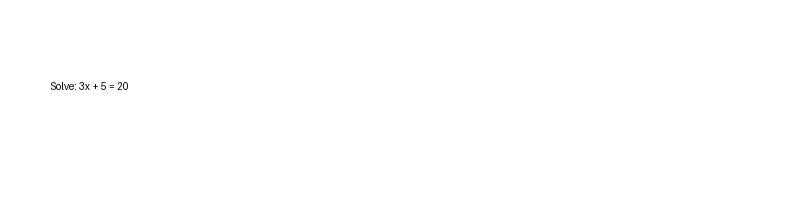

In [165]:
from PIL import Image, ImageDraw

# Create a blank white image
img = Image.new("RGB", (800, 200), color="white")
draw = ImageDraw.Draw(img)

# Text to embed in the image
text = "Solve: 3x + 5 = 20"

# Draw text
draw.text((50, 80), text, fill="black")

# Save image
image_path = "test_equation.png"
img.save(image_path)

print("Generated image:", image_path)
img


In [166]:
extracted = ocr_to_text("test_equation.png")
print("OCR Extracted:", extracted)


OCR Extracted: Solve:3+5 = 20


In [184]:
!pip install paddlepaddle paddleocr


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 7.3 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 21.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 8.0 MB/s eta 0:00:0000:0100:01mm
   ━━━━━━━━━━

In [210]:
!git clone https://github.com/ggerganov/llama.cpp
%cd llama.cpp
!pip install -r requirements.txt

!python convert-hf-to-gguf.py \
    /kaggle/input/models/google/gemma-4/transformers/gemma-4-26b-a4b/1 \
    --outfile gemma4-26b.gguf \
    --outtype q4_k_m


Cloning into 'llama.cpp'...
remote: Enumerating objects: 86811, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 86811 (delta 30), reused 20 (delta 19), pack-reused 86747 (from 2)
Receiving objects: 100% (86811/86811), 358.02 MiB | 34.79 MiB/s, done.
Resolving deltas: 100% (62753/62753), done.
/kaggle/working/mlc-llm/mlc-llm/python/llama.cpp
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/